<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>02 $\rightarrow$ Eye Detection with OpenCV and Haar Cascades</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Facial Feature Localization & Isolated Eye Region Extraction)</span>
</div>

---

## Overview
In this notebook, we detect **Human Eyes** using the pre-trained `haarcascade_eye.xml` classifier.

### Key Concepts Covered:
1. Loading the pre-trained eye cascade classifier (`haarcascade_eye.xml`).
2. Preprocessing images to grayscale for Haar feature extraction.
3. Tuning detection parameters (`scaleFactor=1.1`, `minNeighbors=5`, `minSize=(60, 60)`) for accurate eye localization.
4. Drawing non-destructive bounding boxes.
5. Extracting and visualizing isolated **Eye Regions of Interest (ROIs)**.

---

# Table of Contents 

1. [Import Libraries](#1-import-libraries)
2. [Load the Pre-Trained Eye Classifier](#2-load-the-pre-trained-eye-classifier)
3. [Load and Prepare the Input Image](#3-load-and-prepare-the-input-image)
4. [Detect Eyes with detectMultiScale](#4-detect-eyes-with-detectmultiscale)
5. [Non-Destructive Detection Function](#5-non-destructive-detection-function)
6. [Visualizations](#6-visualizations)
   - 6.1 [Plot 1: Side-by-Side Image Comparison](#61-plot-1-side-by-side-image-comparison)
   - 6.2 [Plot 2: Cropped Gallery of Detected Eyes](#62-plot-2-cropped-gallery-of-detected-eyes)
7. [Key Takeaways](#7-key-takeaways)

---

<a id="1-import-libraries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Import Libraries</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a id="2-load-the-pre-trained-eye-classifier"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Load the Pre-Trained Eye Classifier</span>

In [2]:
eye_cascade_path = 'Haarcascades/haarcascade_eye.xml'
eye_classifier = cv2.CascadeClassifier(eye_cascade_path)

if eye_classifier.empty():
    print("Error: Could not load eye cascade from:", eye_cascade_path)
else:
    print("Eye classifier loaded successfully!")

Eye classifier loaded successfully!


<a id="3-load-and-prepare-the-input-image"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Load and Prepare the Input Image</span>

In [3]:
image_bgr = cv2.imread('assets/images/eye_face.jpg')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Image Size: {image_rgb.shape[1]} x {image_rgb.shape[0]} pixels")

Image Size: 1024 x 1024 pixels


<a id="4-detect-eyes-with-detectmultiscale"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Detect Eyes with `detectMultiScale`</span>

We configure `detectMultiScale` with optimal parameters:
- **`scaleFactor=1.1`**: Fine scale pyramid scanning for small features.
- **`minNeighbors=5`**: Filters candidate overlaps to eliminate spurious noise.
- **`minSize=(60, 60)`**: Enforces a minimum bounding size matching realistic eye dimensions.

In [4]:
eyes = eye_classifier.detectMultiScale(
    image_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(60, 60)
)

# Sort detected eyes from left to right
eyes = sorted(eyes, key=lambda b: b[0])

print(f"Total eyes detected: {len(eyes)}")
for i, (x, y, w, h) in enumerate(eyes, start=1):
    print(f"Eye {i}: Position=({x}, {y}), Size={w}x{h} px")

Total eyes detected: 2
Eye 1: Position=(350, 348), Size=112x112 px
Eye 2: Position=(550, 343), Size=113x113 px


<a id="5-non-destructive-detection-function"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Non-Destructive Detection Function</span>

In [5]:
def detect_eyes(image_rgb, image_gray, scale_factor=1.1, min_neighbors=5, min_size=(60, 60)):
    canvas = image_rgb.copy()
    eye_rects = eye_classifier.detectMultiScale(
        image_gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )
    eye_rects = sorted(eye_rects, key=lambda b: b[0])
    
    for i, (x, y, w, h) in enumerate(eye_rects, start=1):
        # Draw basic blue bounding box (0, 0, 255)
        cv2.rectangle(canvas, (x, y), (x + w, y + h), (0, 0, 255), 4)
        cv2.putText(canvas, f"Eye {i}", (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
    return canvas, eye_rects

detected_image, detected_eyes = detect_eyes(image_rgb, image_gray)

<a id="6-visualizations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Visualizations</span>

<a id="61-plot-1-side-by-side-image-comparison"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Plot 1: Side-by-Side Image Comparison</span>

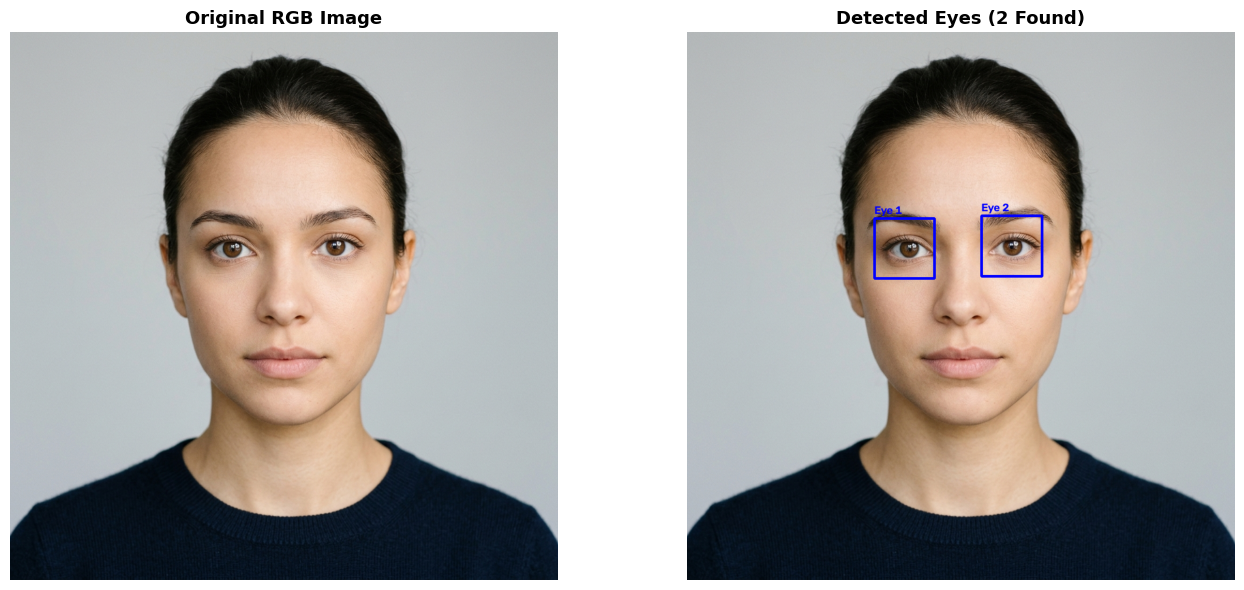

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB Image", fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(detected_image)
axes[1].set_title(f"Detected Eyes ({len(detected_eyes)} Found)", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

<a id="62-plot-2-cropped-gallery-of-detected-eyes"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Plot 2: Cropped Gallery of Detected Eyes</span>

Isolating Left Eye and Right Eye for close inspection.

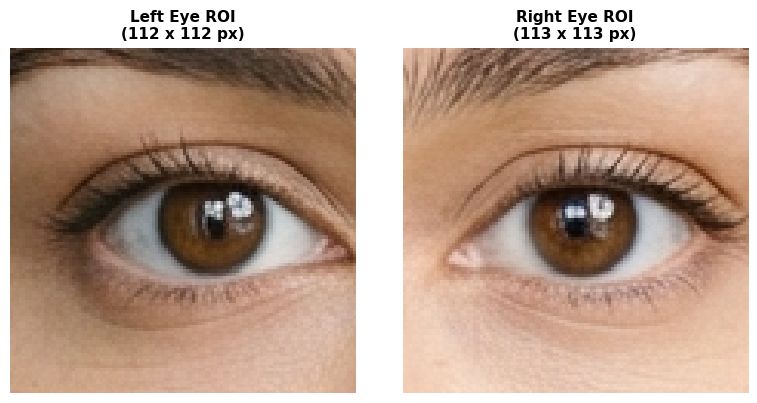

In [7]:
if len(detected_eyes) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    eye_labels = ["Left Eye ROI", "Right Eye ROI"]
    
    for i, (x, y, w, h) in enumerate(detected_eyes):
        eye_crop = image_rgb[y:y+h, x:x+w]
        axes[i].imshow(eye_crop)
        axes[i].set_title(f"{eye_labels[i]}\n({w} x {h} px)", fontsize=11, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

<a id="7-key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Key Takeaways</span>

- **Size Constraints**: Setting `minSize=(60, 60)` ensures small contrast artifacts (like nostrils or skin folds) are cleanly discarded.
- **Next Step**: In Notebook 03, we combine face and eye detection hierarchically to detect eyes strictly within the face boundary.